In [174]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [192]:
df = pd.read_excel("/Users/pp/Documents/Repos/plant_hydro_standalone/data/hainich/eval/cleaned_FP_data_Hainich.xlsx")

In [177]:
df2=df.dropna(subset=['cleaned_FP_data_Hainich'])
df2.columns =df2.values[0,:]
df2 = df2.iloc[2:]
df2['time'] = pd.to_datetime(df2['TIMESTAMP']);

In [178]:
df3 = df2.drop(['time', "TIMESTAMP"],axis=1)
df3.astype(float)
df3['time'] = df2['time']
df3

,FASY_01_1,FASY_02_1,FASY_02_2,FASY_03_1,FASY_03_2,FASY_04_1,FREX_05_1,FREX_06_1,FREX_07_1,FREX_07_2,FREX_08_1,time
4,-0.3548,-0.4754,-0.3742,-0.3863,-0.4599,NaN,NaN,-0.66945,-0.957,NaN,NaN,2023-07-11 12:00:00
6,-0.39095,-0.5306,-0.37895,-0.4202,-0.5182,NaN,NaN,-0.7555,-1.013,NaN,NaN,2023-07-11 13:00:00
8,-0.45785,-0.6106,-0.43095,-0.46925,-0.62385,NaN,NaN,-0.8805,-1.0875,NaN,NaN,2023-07-11 14:00:00
10,-0.5111,-0.6784,-0.47845,-0.5136,-0.7005,NaN,NaN,-0.991,-1.1415,NaN,NaN,2023-07-11 15:00:00
12,-0.55315,-0.744,-0.53255,-0.55905,-0.76805,NaN,NaN,-1.0435,-1.187,NaN,NaN,2023-07-11 16:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...
4308,NaN,NaN,NaN,NaN,NaN,NaN,-1.9575,NaN,NaN,NaN,-0.45395,2023-10-10 07:00:00
4310,NaN,NaN,NaN,NaN,NaN,NaN,-1.925,NaN,NaN,NaN,-0.44805,2023-10-10 08:00:00
4312,NaN,NaN,NaN,NaN,NaN,NaN,-1.923,NaN,NaN,NaN,-0.44225,2023-10-10 09:00:00
4314,NaN,NaN,NaN,NaN,NaN,NaN,-1.9585,NaN,NaN,NaN,-0.4395,2023-10-10 10:00:00


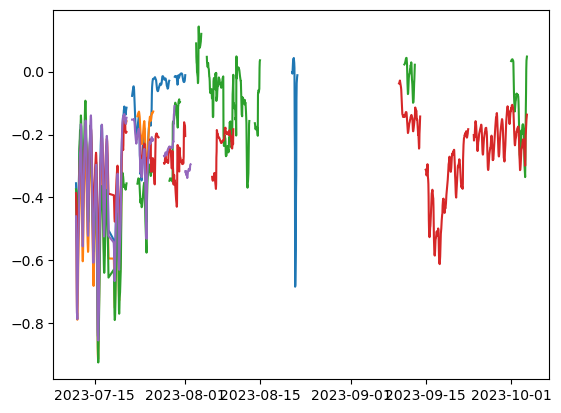

In [179]:
plt.plot(df3['time'] , df3['FASY_01_1'])
plt.plot(df3['time'] , df3['FASY_02_1'])
plt.plot(df3['time'] , df3['FASY_02_2'])
plt.plot(df3['time'] , df3['FASY_03_1'])
plt.plot(df3['time'] , df3['FASY_03_2'])

In [180]:
df3['FAG'] = np.median(df3.iloc[:, 0:6], axis=1)
df3['FAG_075'] = np.quantile(df3.iloc[:, 0:6], axis=1, q=0.75)
df3['FAG_025'] = np.quantile(df3.iloc[:, 0:6], axis=1, q=0.25)

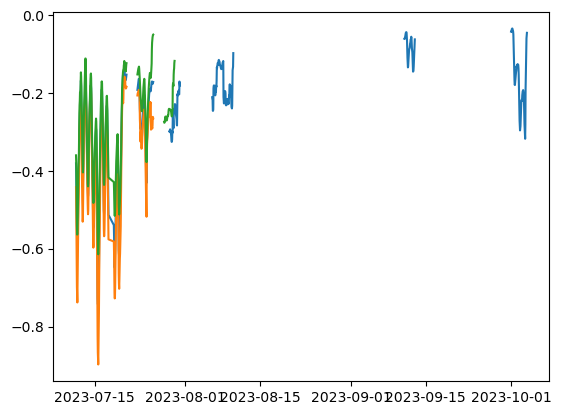

In [185]:
plt.plot(df3['time'] , df3['FAG'])
plt.plot(df3['time'] , df3['FAG_025'])
plt.plot(df3['time'] , df3['FAG_075'])

In [186]:
df3.set_index('time', inplace = True)
df4  = df3.loc['2023-07-1':'2023-7-27']


In [202]:
df4

,FASY_01_1,FASY_02_1,FASY_02_2,FASY_03_1,FASY_03_2,FASY_04_1,FREX_05_1,FREX_06_1,FREX_07_1,FREX_07_2,FREX_08_1,FAG,FAG_075,FAG_025
time,,,,,,,,,,,,,,
2023-07-11 12:00:00,-0.3548,-0.4754,-0.3742,-0.3863,-0.4599,NaN,NaN,-0.66945,-0.957,NaN,NaN,-0.38025,-0.35965,-0.4415
2023-07-11 13:00:00,-0.39095,-0.5306,-0.37895,-0.4202,-0.5182,NaN,NaN,-0.7555,-1.013,NaN,NaN,-0.405575,-0.38195,-0.4937
2023-07-11 14:00:00,-0.45785,-0.6106,-0.43095,-0.46925,-0.62385,NaN,NaN,-0.8805,-1.0875,NaN,NaN,-0.46355,-0.437675,-0.575263
2023-07-11 15:00:00,-0.5111,-0.6784,-0.47845,-0.5136,-0.7005,NaN,NaN,-0.991,-1.1415,NaN,NaN,-0.51235,-0.486613,-0.6372
2023-07-11 16:00:00,-0.55315,-0.744,-0.53255,-0.55905,-0.76805,NaN,NaN,-1.0435,-1.187,NaN,NaN,-0.5561,-0.5377,-0.697763
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-07-27 19:00:00,-0.0152,NaN,NaN,NaN,NaN,NaN,NaN,-0.2419,-0.586,NaN,NaN,NaN,NaN,NaN
2023-07-27 20:00:00,-0.0162,NaN,NaN,NaN,NaN,NaN,NaN,-0.2352,-0.5784,NaN,NaN,NaN,NaN,NaN
2023-07-27 21:00:00,-0.0181,NaN,NaN,NaN,NaN,NaN,NaN,-0.2395,-0.5717,NaN,NaN,NaN,NaN,NaN


In [204]:
dfs = df4[['FAG', 'FAG_025', 'FAG_075']].dropna()

In [206]:
dfs.to_csv("/Users/pp/Documents/Repos/plant_hydro_standalone/data/hainich/eval/stem_water_pot.csv")
dfs

,FAG,FAG_025,FAG_075
time,,,
2023-07-11 12:00:00,-0.38025,-0.4415,-0.35965
2023-07-11 13:00:00,-0.405575,-0.4937,-0.38195
2023-07-11 14:00:00,-0.46355,-0.575263,-0.437675
2023-07-11 15:00:00,-0.51235,-0.6372,-0.486613
2023-07-11 16:00:00,-0.5561,-0.697763,-0.5377
...,...,...,...
2023-07-25 19:00:00,-0.17625,-0.29045,-0.0619
2023-07-25 20:00:00,-0.1761,-0.283075,-0.056225
2023-07-25 21:00:00,-0.1745,-0.260675,-0.0521


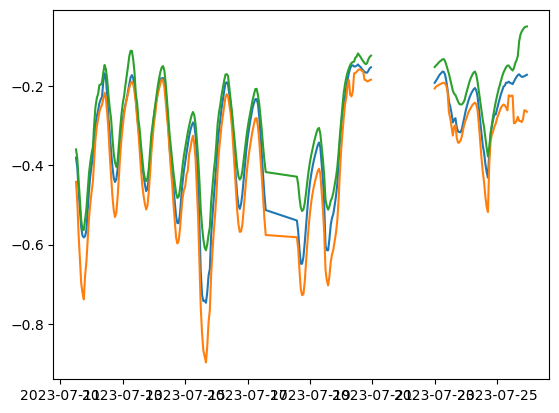

In [201]:
plt.plot(df4['FAG'])
plt.plot(df4['FAG_025'])
plt.plot(df4['FAG_075'])

In [200]:
df3[['FAG', 'FAG_025', 'FAG_075']].dropna()

,FAG,FAG_025,FAG_075
time,,,
2023-07-11 12:00:00,-0.38025,-0.4415,-0.35965
2023-07-11 13:00:00,-0.405575,-0.4937,-0.38195
2023-07-11 14:00:00,-0.46355,-0.575263,-0.437675
2023-07-11 15:00:00,-0.51235,-0.6372,-0.486613
2023-07-11 16:00:00,-0.5561,-0.697763,-0.5377
...,...,...,...
2023-07-25 19:00:00,-0.17625,-0.29045,-0.0619
2023-07-25 20:00:00,-0.1761,-0.283075,-0.056225
2023-07-25 21:00:00,-0.1745,-0.260675,-0.0521


In [188]:
df5 = df4.groupby([df4.index.hour]).mean()

In [189]:
df5

,FASY_01_1,FASY_02_1,FASY_02_2,FASY_03_1,FASY_03_2,FASY_04_1,FREX_05_1,FREX_06_1,FREX_07_1,FREX_07_2,FREX_08_1,FAG,FAG_075,FAG_025
time,,,,,,,,,,,,,,
0,-0.248186,-0.383109,-0.412786,-0.310387,-0.326342,NaN,NaN,-0.310857,-0.98816,NaN,NaN,-0.321709,-0.287898,-0.367592
1,-0.230904,-0.354364,-0.3912,-0.293546,-0.300871,NaN,NaN,-0.263027,-0.951647,NaN,NaN,-0.298952,-0.266473,-0.340844
2,-0.215132,-0.327905,-0.3647,-0.278979,-0.276375,NaN,NaN,-0.213063,-0.91569,NaN,NaN,-0.277945,-0.243836,-0.316098
3,-0.20235,-0.303527,-0.340086,-0.268192,-0.256225,NaN,NaN,-0.171917,-0.883203,NaN,NaN,-0.260223,-0.224922,-0.293352
4,-0.191289,-0.283605,-0.322973,-0.257596,-0.238679,NaN,NaN,-0.139217,-0.85443,NaN,NaN,-0.243425,-0.208998,-0.277924
5,-0.182239,-0.267505,-0.310591,-0.246604,-0.225942,NaN,NaN,-0.114497,-0.829213,NaN,NaN,-0.230768,-0.196159,-0.263417
6,-0.174311,-0.253191,-0.302314,-0.238958,-0.214038,NaN,NaN,-0.106713,-0.80705,NaN,NaN,-0.220157,-0.185166,-0.252557
7,-0.170896,-0.246291,-0.305255,-0.238804,-0.208092,NaN,NaN,-0.147623,-0.796707,NaN,NaN,-0.214636,-0.182159,-0.254361
8,-0.176514,-0.254127,-0.316936,-0.2425,-0.215008,NaN,NaN,-0.227187,-0.80461,NaN,NaN,-0.220675,-0.189711,-0.263383


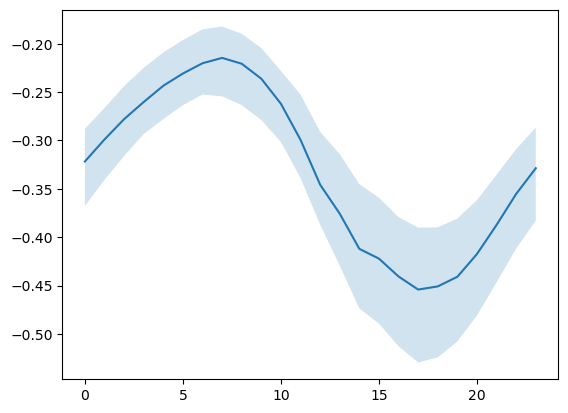

In [190]:
plt.plot(df5['FAG'])
plt.fill_between(df5.index, df5['FAG_075'].astype(float),df5['FAG_025'].astype(float), alpha=0.2)

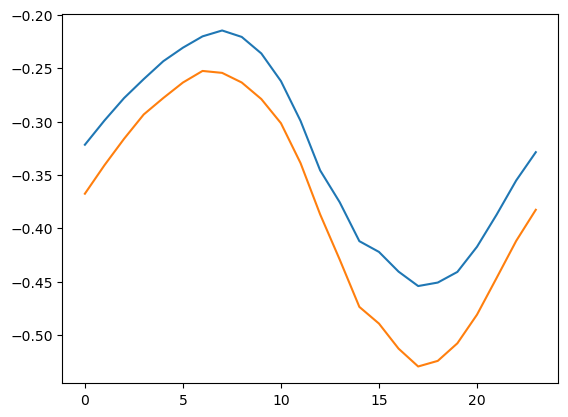

In [191]:
plt.plot(df5['FAG'])
plt.plot(df5['FAG_025'])

TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

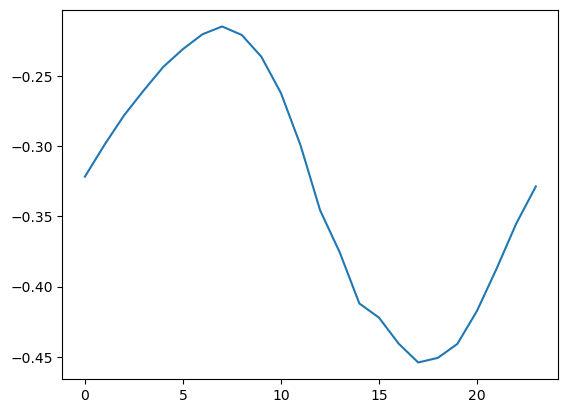

In [161]:
plt.plot(df5['FAG'])
plt.fill_between(df5.index, df5['FAG_025'], df5['FAG'])